## **Salary Prediction Model**

### **Objective**
Xây dựng mô hình dự đoán mức lương từ thông tin tuyển dụng và dữ liệu kỹ năng được trích xuất.

### **Dataset**
- jobs_cleaned.parquet
- skills.parquet

### **Evaluation Metrics**
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

### **Models**
- Baseline Global Median
- Baseline Median by Title
- Ridge Regression
- LightGBM

### **Experimental Settings**
- Stratified 5-Fold Cross Validation
- random_state = 42

## **SECTION 1 - Load Data**

In [1]:
!pip install lightgbm -q


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### **Load Data**

Tải dữ liệu đã được tiền xử lý từ bước Data Processing và import các thư viện cần thiết cho quá trình xây dựng mô hình.

In [2]:
import os
import sys
# Thêm đường dẫn để import từ thư mục src
sys.path.append(os.path.abspath(os.path.join('..')))
from src.feature_engineer import (build_skill_aggregates,get_skill_matrix)
from src.evaluation import (evaluate_model,get_model_summary)
from src.processor import (group_rare_categories, clean_industry, calculate_skill_coverage)
from src.modeling import (tune_ridge_alpha, build_ridge_pipeline, build_lgbm_pipeline)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import logging
import joblib
import hashlib
import re
from scipy.stats import ttest_rel
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import Ridge
from lightgbm import LGBMRegressor


warnings.filterwarnings("ignore")
logging.getLogger('lightgbm').setLevel(logging.ERROR)


In [4]:
jobs = pd.read_parquet("../data/processed/jobs_cleaned.parquet")
skills = pd.read_parquet("../data/processed/skills.parquet")

print(jobs.shape)
print(skills.shape)

(3181, 27)
(56335, 8)


## **SECTION 2 - Data Quality Check**
 
**Mục tiêu** của bước này là đánh giá chất lượng dữ liệu trước khi xây dựng mô hình.

Các nội dung được kiểm tra gồm:

- Kích thước của tập jobs và skills
- Tỷ lệ giá trị thiếu (missing values)
- Tỷ lệ bao phủ giữa dữ liệu jobs và skills
- Bản ghi trùng lặp (duplicate records)

Việc kiểm tra giúp đảm bảo dữ liệu đủ tin cậy trước khi đưa vào huấn luyện mô hình.

In [5]:
print("=== JOBS INFO ===")
jobs.info()
print("\n=== SKILLS INFO ===")
skills.info()

=== JOBS INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3181 entries, 0 to 3180
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   job_id                     3181 non-null   int64  
 1   url                        3181 non-null   object 
 2   job_title                  3181 non-null   object 
 3   company                    3181 non-null   object 
 4   location                   3177 non-null   object 
 5   salary                     3181 non-null   object 
 6   experience                 3181 non-null   object 
 7   education                  3181 non-null   object 
 8   job_level                  3181 non-null   object 
 9   employment_type            3181 non-null   object 
 10  industry                   3112 non-null   object 
 11  platform_required_skills   3181 non-null   object 
 12  platform_preferred_skills  2440 non-null   object 
 13  specialization             244

In [6]:
print("=== JOB MISSING VALUES ===")
print(jobs.isna().mean().sort_values(ascending=False).loc[lambda x: x > 0])
print("\n=== SKILLS MISSING VALUES ===")
print(skills.isna().mean().sort_values(ascending=False).loc[lambda x: x > 0])

=== JOB MISSING VALUES ===
platform_preferred_skills    0.232946
specialization               0.232946
industry                     0.021691
location                     0.001257
dtype: float64

=== SKILLS MISSING VALUES ===
min_years    0.932316
level        0.804864
dtype: float64


In [7]:
print(f"Duplicate jobs: {jobs.duplicated().sum()}")
print(f"Duplicate skills: {skills.duplicated().sum()}")

Duplicate jobs: 0
Duplicate skills: 0


In [8]:
coverage = calculate_skill_coverage(jobs,skills)
print(f"Skill coverage: {coverage:.2%}")

Skill coverage: 99.59%


## **SECTION 3 - Target Engineering**

###  **3.1 Negotiable Analysis**

**Research Question 1: Can negotiable jobs be removed safely?**

In [9]:
jobs.groupby("is_thoa_thuan")["source"].value_counts(normalize=True)

is_thoa_thuan  source
False          topcv     0.879567
               itviec    0.120433
True           topcv     0.669407
               itviec    0.330593
Name: proportion, dtype: float64

In [10]:
jobs.groupby("is_thoa_thuan")["job_level"].value_counts(normalize=True)

is_thoa_thuan  job_level         
False          Nhân viên             0.609608
               Trưởng nhóm           0.217185
               Intern                0.074425
               Senior                0.041949
               Quản lý / Giám sát    0.031800
               Trưởng/Phó phòng      0.018268
               Junior                0.004060
               Giám đốc              0.002030
               Fresher               0.000677
True           Nhân viên             0.597769
               Trưởng nhóm           0.159131
               Senior                0.112155
               Quản lý / Giám sát    0.049325
               Intern                0.032883
               Trưởng/Phó phòng      0.030534
               Junior                0.012918
               Giám đốc              0.003523
               Fresher               0.001762
Name: proportion, dtype: float64

**Nhận xét: Phân tích nhóm công việc có mức lương thỏa thuận**

Hơn 50% tin tuyển dụng trong tập dữ liệu được gắn nhãn **lương thỏa thuận (negotiable)**.

Trước khi loại bỏ, cần kiểm tra xem nhóm này có khác biệt về phân bố đặc trưng hay không nhằm đánh giá nguy cơ selection bias.


### **Decision 1**

#### **3.1.1 Remove Negotiable Salaries**

In [11]:
jobs_model = jobs[jobs["is_thoa_thuan"] == False].copy()
print("Remaining jobs:", jobs_model.shape)

Remaining jobs: (1478, 27)


#### **3.1.2 Examine Salary Distribution**

In [12]:
jobs_model["avg_salary"].describe(
    percentiles=[
        0.90,
        0.95,
        0.97,
        0.99,
        0.995
    ]
)

count      1478.000000
mean        236.848241
std        7217.937359
min           0.000000
50%          22.500000
90%          47.500000
95%          56.250000
97%          63.231400
99%          75.000000
99.5%        86.037800
max      275000.000000
Name: avg_salary, dtype: float64

<Axes: >

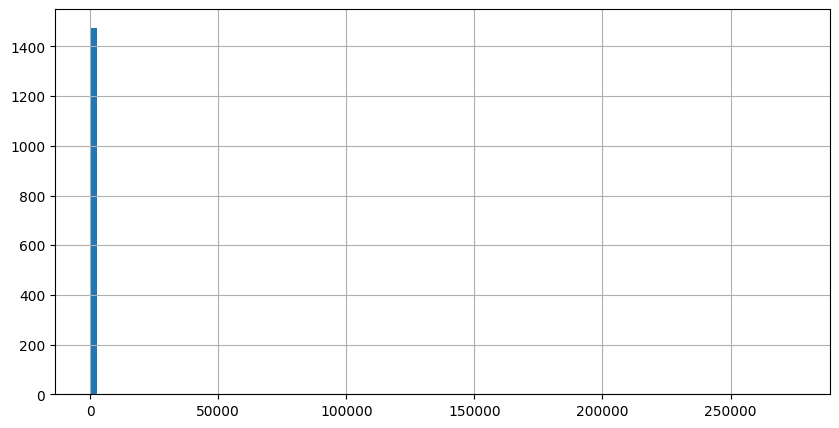

In [13]:
jobs_model["avg_salary"].hist(bins=100,figsize=(10,5))

#### **3.1.3 Detect Extreme Salary Values**

In [14]:
jobs_model.nlargest(20,"avg_salary")[
    [
        "job_title",
        "salary",
        "min_salary",
        "max_salary",
        "avg_salary",
        "source"
    ]
]

,job_title,salary,min_salary,max_salary,avg_salary,source
1848,Nhân Viên Idea Creator (Mảng POD - AI),"10,000,000 - 12,000,000 USD",250000.00,300000.00,275000.00,topcv
1602,Chuyên Viên SRE,"Tới 1,500,000 USD",0.00,37500.00,37500.00,topcv
3139,Solution Architect - Salary Up to $5000,Up to $5000,0.00,125.00,125.00,itviec
2082,Technical Manager (SaaS),"Tới 4,000 USD",0.00,100.00,100.00,topcv
3175,VIETTEL SOLUTIONS - Solutions Architect,"2,500 - 5,000 USD",62.50,125.00,93.75,itviec
2716,(HN) Expert/Manager Software Engineering,"3,000 - 4,000 USD",75.00,100.00,87.50,itviec
3155,Technical Lead (Golang) ~ Upto 3500$,Upto 3500$,0.00,87.50,87.50,itviec
3174,VIETTEL SOLUTIONS - Project Manager,"2,000 - 4,998 USD",50.00,124.95,87.47,itviec
2723,[HYBRID] Senior Java Developer,"3,200 - 3,500 USD",80.00,87.50,83.75,itviec
3092,Senior Python Developer,"3,200 - 3,500 USD",80.00,87.50,83.75,itviec


In [15]:
jobs_model[jobs_model["avg_salary"] > 500][
    [
        "job_title",
        "salary",
        "avg_salary",
        "source"
    ]
]

,job_title,salary,avg_salary,source
1602,Chuyên Viên SRE,"Tới 1,500,000 USD",37500.0,topcv
1848,Nhân Viên Idea Creator (Mảng POD - AI),"10,000,000 - 12,000,000 USD",275000.0,topcv


#### **3.1.4 Remove Salary Outliers**

In [16]:
bad_salary_mask = jobs_model["avg_salary"] > 500
jobs_model = jobs_model.loc[~bad_salary_mask].copy()
n_removed = bad_salary_mask.sum()
print(f"Removed {n_removed} salary outliers")

Removed 2 salary outliers


**Kết luận**

Các tin tuyển dụng có mức lương thỏa thuận không thể sử dụng trực tiếp cho bài toán hồi quy do thiếu biến mục tiêu dạng số.

Sau khi đánh giá nguy cơ selection bias, nhóm quyết định loại bỏ các quan sát này khỏi tập modeling.

Đồng thời, các giá trị lương lớn hơn 500 triệu VNĐ/tháng được xem là outlier và bị loại bỏ để giảm ảnh hưởng của nhiễu dữ liệu.

### **3.2 Final Salary Distribution Review**

Sau khi loại bỏ các bản ghi lương thỏa thuận và các outlier rõ ràng (>500 triệu VNĐ/tháng), phân phối lương được đánh giá lại trước khi xây dựng biến mục tiêu cho mô hình.

### **3.3 Log Transformation**

Phân phối lương vẫn lệch phải (right-skewed), điều này có thể ảnh hưởng đến các mô hình hồi quy tuyến tính.

Để giảm độ lệch và ổn định phương sai, nhóm áp dụng phép biến đổi:

> log_salary=log(1+avg_salary)

**Tạo biến mục tiêu**

In [17]:
jobs_model["log_salary"] = np.log1p(jobs_model["avg_salary"])
TARGET = "log_salary"

**Kiểm tra phân phối sau biến đổi**

In [18]:
jobs_model["log_salary"].describe()

count    1476.000000
mean        3.088477
std         0.658041
min         0.000000
25%         2.772589
50%         3.157000
75%         3.511545
max         4.836282
Name: log_salary, dtype: float64

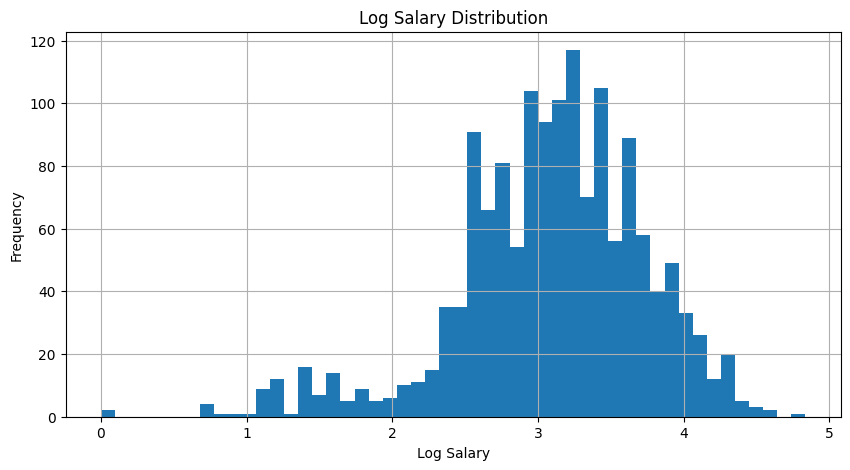

In [19]:
jobs_model["log_salary"].hist(bins=50,figsize=(10,5))
plt.title("Log Salary Distribution")
plt.xlabel("Log Salary")
plt.ylabel("Frequency")
plt.show()

In [20]:
print("Skewness before:",jobs_model["avg_salary"].skew())
print("Skewness after:",jobs_model["log_salary"].skew())

Skewness before: 1.332011920563557
Skewness after: -0.8372211851422461


**Kết luận:**

Sau khi loại bỏ các outlier rõ ràng, phân phối lương còn lại được đánh giá là hợp lý và không cần áp dụng winsorization.

Nhóm giữ nguyên các mức lương cao để bảo toàn thông tin thị trường lao động.

Cuối cùng, biến mục tiêu được chuyển sang thang logarit nhằm giảm độ lệch của phân phối và hỗ trợ quá trình huấn luyện mô hình.

## **SECTION 4 - Job Metadata Features**

### **4.1 Cardinality Analysis**

In [21]:
job_features = [
    "source",
    "location",
    "industry",
    "specialization",
    "education",
    "experience_years",
    "job_level",
    "standardized_title"
]

for col in job_features:
    print(f"{col}: {jobs_model[col].nunique()}")

source: 2
location: 18
industry: 55
specialization: 1154
education: 8
experience_years: 19
job_level: 9
standardized_title: 97


**Feature Selection Decisions**

Các đặc trưng được đánh giá dựa trên số lượng category, ý nghĩa nghiệp vụ và khả năng hỗ trợ dự đoán lương.

| Feature            | Decision                       |
| ------------------ | ------------------------------ |
| source             | Keep, One-Hot                  |
| location           | Keep, One-Hot                  |
| education          | Keep, One-Hot                  |
| experience_years   | Keep                           |
| specialization     | Exclude                        |
| job_level          | Keep, One-Hot                  |
| industry           | Keep, One-Hot                  |
| standardized_title | Keep, One-Hot                  |


### **4.2 Industry Handling**

In [22]:
jobs_model["industry"].value_counts().head(30)

industry
IT - Phần mềm                            835
Giáo dục / Đào tạo                        54
IT Services and IT Consulting             49
Marketing / Truyền thông / Quảng cáo      47
Khác                                      35
Software Products and Web Services        32
Bán lẻ - Hàng tiêu dùng - FMCG            31
Viễn thông                                29
Sản xuất                                  27
Thương mại điện tử                        25
Financial Services                        22
Dược phẩm / Y tế / Công nghệ sinh học     21
IT - Phần cứng                            20
Tài chính                                 16
Software Development Outsourcing          14
Banking                                   14
Bất động sản                              14
Giải trí                                  13
Logistics - Vận tải                       11
Xây dựng                                  10
Nhà hàng / Khách sạn                      10
Điện tử / Điện lạnh                        9
N

**Nhận xét:** 

Biến `industry` có 56 nhóm ngành.

Nhóm thử nghiệm một phương án feature engineering riêng bằng cách gộp các ngành thành 15 nhóm lớn (`industry_cleaned`).

Kết quả được trình bày trong phần **Feature Engineering Experiments**.

Do mức cải thiện không đáng kể và không xuất hiện nhất quán trên tất cả mô hình, nghiên cứu quyết định giữ nguyên `industry` gốc trong pipeline cuối cùng.

### **4.3 Metadata Feature Set cuối cùng**

In [23]:
NUMERIC_FEATURES = ["experience_years"]
CATEGORICAL_FEATURES = [
    "source",
    "location",
    "education",
    "job_level",
    "industry",
    "standardized_title"
]

`specialization` được loại khỏi mô hình do trùng lặp thông tin với industry và standardized_title.

## **SECTION 5 - Skill Feature Engineering**

### **5.1 Skill Overview**

In [24]:
skills["final_canonical"].nunique()

2762

**Nhận xét:**

* 1476 jobs

* 2762 canonical skills

=> Số skill unique > số job

=> `Không thể` **One-Hot** toàn bộ skill

In [25]:
skills["category"].value_counts()

category
Soft Skill                              8740
Infrastructure & DevOps                 8023
Engineering Concepts & Methodologies    7822
Tool & Platform                         5601
Domain Knowledge                        5026
Programming Language                    3296
Framework / Library                     3229
Database                                2867
AI/ML/Data                              2625
Testing & QA                            2574
Other                                   2259
Data Engineering & Analytics            1870
Design & UX                             1092
Embedded & Firmware                      693
IT Support & Hardware                    618
Name: count, dtype: int64

In [26]:
skills["level"].value_counts(dropna=False)

level
None            45342
expert           5684
basic            2761
intermediate     2548
Name: count, dtype: int64

**Nhận xét:** 
Thay vì **One-Hot** từng `skill` theo `level`, nhóm sử dụng các biến tổng hợp (aggregate features) phản ánh số lượng skill ở từng mức độ.

**Ví dụ:** 
*   n_expert_skills
*   n_intermediate_skills
*   n_basic_skills

In [27]:
skills.groupby("job_id").size().describe()

count    3168.000000
mean       17.782513
std        10.321469
min         1.000000
25%        10.000000
50%        16.000000
75%        23.000000
max        86.000000
dtype: float64

### **5.2 Build Aggregate Features**
**Mục tiêu:** từ skills -> skill_agg

Các đặc trưng kỹ năng được xây dựng thông qua hàm `build_skill_aggregates()` trong module `feature_engineer.py`.

Hàm này thực hiện:

- Đếm tổng số kỹ năng của từng job
- Đếm Required / Preferred skills
- Đếm số kỹ năng theo category
- Đếm số kỹ năng theo level
- Xây dựng các đặc trưng liên quan tới yêu cầu kinh nghiệm

Kết quả trả về là bảng `skill_agg` với mỗi dòng tương ứng một tin tuyển dụng.

#### **5.2.1 Kiểm tra output**

In [28]:
skill_agg = build_skill_aggregates(skills)
skill_agg.shape

(3168, 24)

In [29]:
skill_agg.head()

,job_id,n_skills,n_preferred,n_required,cat_ai_ml_data,cat_data_engineering_&_analytics,cat_database,cat_design_&_ux,cat_domain_knowledge,cat_embedded_&_firmware,...,cat_other,cat_programming_language,cat_soft_skill,cat_testing_&_qa,cat_tool_&_platform,level_basic,level_expert,level_intermediate,required_experience_level,has_year_requirement
0,1,19,1,18,0,0,3,0,3,0,...,1,3,4,0,0,1.0,0.0,1.0,0.0,0
1,2,9,2,7,0,0,0,0,2,0,...,0,2,1,0,0,0.0,0.0,0.0,0.0,0
2,3,21,0,21,0,2,3,0,4,0,...,0,1,2,0,0,0.0,2.0,0.0,0.0,0
3,4,24,5,19,0,0,1,0,1,0,...,0,0,1,0,1,0.0,3.0,2.0,1.0,1
4,5,19,8,11,0,0,0,0,3,0,...,5,0,7,0,0,0.0,1.0,0.0,3.0,1


In [30]:
skill_agg.describe()

,job_id,n_skills,n_preferred,n_required,cat_ai_ml_data,cat_data_engineering_&_analytics,cat_database,cat_design_&_ux,cat_domain_knowledge,cat_embedded_&_firmware,...,cat_other,cat_programming_language,cat_soft_skill,cat_testing_&_qa,cat_tool_&_platform,level_basic,level_expert,level_intermediate,required_experience_level,has_year_requirement
count,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.00000,...,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.0,3168.000000
mean,1593.160354,17.782513,3.900568,13.881944,0.828598,0.590278,0.904987,0.344697,1.586490,0.21875,...,0.713068,1.040404,2.758838,0.812500,1.767992,0.871528,1.794192,0.804293,1.788984,0.612689
std,918.813377,10.321469,4.460389,8.527780,2.950702,1.946569,1.660895,1.312252,2.177931,1.55840,...,1.608136,1.481262,2.278644,2.476707,2.231649,1.857125,2.709478,2.027959,1.964282,0.487213
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,796.750000,10.000000,0.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
50%,1594.500000,16.000000,3.000000,12.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.00000,...,0.000000,0.000000,2.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.0,1.000000
75%,2389.250000,23.000000,6.000000,18.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.00000,...,1.000000,2.000000,4.000000,0.000000,3.000000,1.000000,3.000000,1.000000,3.0,1.000000
max,3181.000000,86.000000,37.000000,80.000000,33.000000,24.000000,16.000000,27.000000,17.000000,27.00000,...,20.000000,9.000000,17.000000,27.000000,19.000000,24.000000,25.000000,49.000000,13.0,1.000000


#### **5.2.2 Merge vào jobs_model**

In [31]:
model_base = (jobs_model.merge(skill_agg,on="job_id",how="left"))

In [32]:
# Check 
model_base.shape

(1476, 51)

In [33]:
model_base.head()

,job_id,url,job_title,company,location,salary,experience,education,job_level,employment_type,...,cat_other,cat_programming_language,cat_soft_skill,cat_testing_&_qa,cat_tool_&_platform,level_basic,level_expert,level_intermediate,required_experience_level,has_year_requirement
0,1,https://www.topcv.vn/viec-lam/lap-trinh-vien-n...,Lập Trình Viên (.Net) - Không Yêu Cầu Kinh Ngh...,Công ty cổ phần công nghệ và giải pháp trực tu...,Hà Nội,8 - 20 triệu,2 năm,Đại Học trở lên,Nhân viên,Toàn thời gian,...,1.0,3.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,3,https://www.topcv.vn/viec-lam/backend-lead-eng...,Backend Lead Engineer,CÔNG TY TNHH LEVER SPHERE VIỆT NAM,Hà Nội,50 - 70 triệu,3 năm,Đại Học trở lên,Trưởng nhóm,Toàn thời gian,...,0.0,1.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0
2,4,https://www.topcv.vn/viec-lam/lap-trinh-vien-n...,Lập Trình Viên Nodejs Đi Làm Ngay Tại Hà Nội,Công ty cổ phần giải pháp MKT,Hà Nội,Tới 30 triệu,1 năm,Đại Học trở lên,Nhân viên,Toàn thời gian,...,0.0,0.0,1.0,0.0,1.0,0.0,3.0,2.0,1.0,1.0
3,5,https://www.topcv.vn/viec-lam/ky-su-tu-van-man...,Kỹ Sư Tư Vấn Mạng/ Presale Network Engineer,Công ty Cổ phần Viễn thông - Tin học Bưu điện ...,Hà Nội,Tới 45 triệu,3 năm,Cao Đẳng trở lên,Nhân viên,Toàn thời gian,...,5.0,0.0,7.0,0.0,0.0,0.0,1.0,0.0,3.0,1.0
4,6,https://www.topcv.vn/viec-lam/nhan-vien-ky-thu...,Nhân Viên Kỹ Thuật IT - Dự Án Xây Dựng Cao Tần...,"CÔNG TY CỔ PHẦN XÂY DỰNG, THƯƠNG MẠI VÀ VẬT LI...",Hưng Yên,Tới 15 triệu,2 năm,Cao Đẳng trở lên,Nhân viên,Toàn thời gian,...,0.0,0.0,2.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0


**CheckPoint 1**
**Mục tiêu:** Xem còn missing nào không.

In [34]:
model_base.isna().sum().sort_values(ascending=False).head(20)

specialization                              178
platform_preferred_skills                   178
industry                                     14
cat_domain_knowledge                          8
cat_embedded_&_firmware                       8
cat_engineering_concepts_&_methodologies      8
cat_framework___library                       8
cat_it_support_&_hardware                     8
cat_infrastructure_&_devops                   8
cat_other                                     8
cat_programming_language                      8
cat_soft_skill                                8
n_skills                                      8
n_required                                    8
n_preferred                                   8
cat_database                                  8
cat_data_engineering_&_analytics              8
cat_design_&_ux                               8
cat_ai_ml_data                                8
level_expert                                  8
dtype: int64

**Nhận xét:**

Sau khi merge dữ liệu kỹ năng, một số giá trị thiếu xuất hiện do:

- Một số job không có thông tin kỹ năng
- Một số thuộc tính metadata thiếu từ dữ liệu gốc

Các giá trị này được xử lý trước khi xây dựng tập dữ liệu modeling.

**Giải quyết skill features**

In [35]:
model_base[model_base["n_skills"].isna()][["job_id","job_title","source"]]

,job_id,job_title,source
70,115,"Nhân Viên IT Phần Cứng , Phần Mềm - Lương Từ 8...",topcv
200,346,Nhân Viên IT Phần Cứng,topcv
486,876,Giáo Viên Part-Time - Sinh Viên Ngành Công Ngh...,topcv
537,999,CTV Kỹ Thuật Viễn Thông,topcv
683,1278,Nhân Viên IT,topcv
803,1486,Chuyên Viên IT,topcv
872,1618,Nhân Viên Công Nghệ Thông Tin - Quản Lý Phần Mềm,topcv
1051,1945,Thực Tập Sinh Lập Trình GIS,topcv


In [36]:
skill_feature_cols = [c for c in skill_agg.columns if c != "job_id"]
model_base[skill_feature_cols] = (model_base[skill_feature_cols].fillna(0))

In [37]:
model_base.isna().sum().sort_values(ascending=False).head(20)

specialization               178
platform_preferred_skills    178
industry                      14
location                       1
job_title                      0
job_id                         0
url                            0
experience                     0
education                      0
salary                         0
company                        0
employment_type                0
job_level                      0
platform_required_skills       0
job_description                0
requirement                    0
standardized_title             0
source                         0
salary_raw                     0
min_salary                     0
dtype: int64

**Giải quyết Industry Missing**

In [38]:
model_base["industry"] = (model_base["industry"].fillna("Unknown"))
model_base.isna().sum().sort_values(ascending=False).head(20)

specialization               178
platform_preferred_skills    178
location                       1
job_title                      0
url                            0
job_id                         0
company                        0
education                      0
job_level                      0
salary                         0
experience                     0
industry                       0
employment_type                0
platform_required_skills       0
job_description                0
requirement                    0
standardized_title             0
source                         0
salary_raw                     0
min_salary                     0
dtype: int64

**Giải quyết Location Missing**

In [39]:
model_base["location"] = (model_base["location"].fillna("Unknown"))
model_base["location"].isna().sum()

np.int64(0)

### **5.3 Chuẩn bị tập dữ liệu cho mô hình**

Các cột văn bản thô và những trường dữ liệu không sử dụng được loại bỏ trước khi huấn luyện mô hình.

Chỉ các đặc trưng có cấu trúc được giữ lại nhằm đảm bảo khả năng tái lập kết quả (reproducibility) và tránh nguy cơ rò rỉ thông tin ngoài ý muốn từ các trường văn bản tự do (free-text content).

In [40]:
DROP_COLS = [
    "url",
    "salary",
    "job_description",
    "requirement",
    "platform_required_skills",
    "platform_preferred_skills",
    "specialization",
    "company"
]

model_ready = (model_base.drop(columns=DROP_COLS,errors="ignore"))

### **Validation**

In [41]:
model_ready.shape

(1476, 43)

In [42]:
model_ready.isna().sum().sum()

np.int64(0)

### **5.4 Export Final Modeling Dataset**

In [43]:
model_ready.to_parquet("../data/processed/features_wide.parquet",index=False)
pd.read_parquet("../data/processed/features_wide.parquet").shape

(1476, 43)

## **SECTION 06 - Modeling Setup**

### **6.1 Xác định biến mục tiêu (Target)**

Biến mục tiêu dùng để dự đoán là `log_salary` được xây dựng ở Section 3 thông qua phép biến đổi:

> log_salary = log(1 + avg_salary)

Tại mục này chỉ thực hiện kiểm tra lại phân phối và xác nhận biến mục tiêu trước khi huấn luyện mô hình.

In [44]:
TARGET = "log_salary"
model_ready[[TARGET]].describe()

,log_salary
count,1476.000000
mean,3.088477
std,0.658041
min,0.000000
25%,2.772589
50%,3.157000
75%,3.511545
max,4.836282


### **Distribution Check**

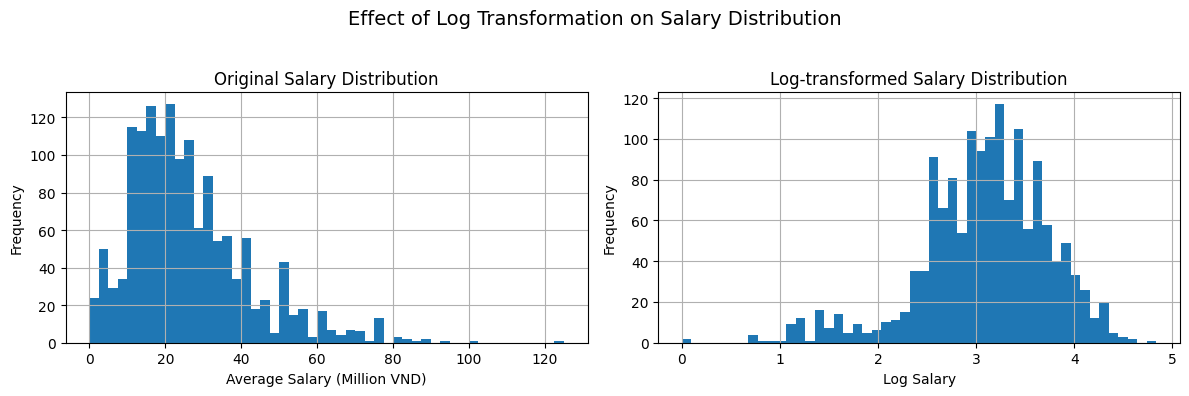

In [45]:
# Minh họa cả trước và sau khi log transform
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

jobs_model["avg_salary"].hist(bins=50,ax=axes[0])
axes[0].set_title("Original Salary Distribution")
axes[0].set_xlabel("Average Salary (Million VND)")
axes[0].set_ylabel("Frequency")

np.log1p(jobs_model["avg_salary"]).hist(bins=50,ax=axes[1])
axes[1].set_title("Log-transformed Salary Distribution")
axes[1].set_xlabel("Log Salary")
axes[1].set_ylabel("Frequency")

plt.suptitle("Effect of Log Transformation on Salary Distribution",fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### **6.2 Chiến lược phân tầng (Stratified Cross-Validation)**

Về lý thuyết, quá trình Cross-Validation nên được phân tầng đồng thời theo **nhóm lương (salary quantile)** và **nguồn dữ liệu (source)**.

Tuy nhiên, một số tổ hợp giữa nguồn dữ liệu và nhóm lương có số lượng mẫu quá ít (ví dụ: các tin tuyển dụng từ **ITViec** thuộc nhóm lương thấp nhất chỉ chiếm rất ít quan sát), khiến việc phân tầng đồng thời theo cả hai biến không khả thi khi sử dụng 5-fold Cross-Validation.

Do đó, đánh giá cuối cùng được thực hiện bằng cách **phân tầng theo nhóm lương** (`salary_bin`) nhằm đảm bảo phân phối mức lương tương đồng giữa các fold.

Trong khi đó, biến **source** vẫn được giữ lại như một đặc trưng đầu vào của mô hình để mô hình có thể học được sự khác biệt về phân phối lương giữa **TopCV** và **ITViec**.

In [46]:
model_ready["salary_bin"] = pd.qcut(model_ready["log_salary"],q=5,labels=False)

In [47]:
# Check
model_ready["salary_bin"].value_counts()

salary_bin
2    309
0    305
1    290
3    286
4    286
Name: count, dtype: int64

**Bias Analysis (giữ lại để viết report)**

In [48]:
pd.crosstab(model_ready["salary_bin"],model_ready["source"],normalize="index")

source,itviec,topcv
salary_bin,,
0,0.003279,0.996721
1,0.013793,0.986207
2,0.064725,0.935275
3,0.139860,0.860140
4,0.395105,0.604895


### **6.3 Feature Sets**

#### **Feature Set A**

Chỉ sử dụng các đặc trưng mô tả thông tin tuyển dụng (metadata).

Tập đặc trưng này đóng vai trò là mô hình học máy cơ sở (baseline),
giúp đánh giá mức độ dự đoán lương chỉ dựa trên thông tin tuyển dụng
mà không sử dụng bất kỳ đặc trưng nào được trích xuất từ kỹ năng.

In [49]:
FEATURES_A = [
    "source",
    "location",
    "industry",
    "education",
    "job_level",
    "standardized_title",
    "experience_years"
]

#### **Feature Set B**

Bao gồm các đặc trưng metadata kết hợp với các đặc trưng tổng hợp
được xây dựng từ dữ liệu kỹ năng.

Mức cải thiện hiệu năng từ **Feature Set A** sang **Feature Set B**
được sử dụng để định lượng giá trị mà pipeline trích xuất kỹ năng
mang lại cho bài toán dự đoán lương.

In [50]:
AGG_FEATURES = [
    c
    for c in model_ready.columns
    if (
        c.startswith("n_")
        or c.startswith("cat_")
        or c.startswith("level_")
        or c in [
            "max_min_years",
            "mean_min_years",
            "has_year_requirement"
        ]
    )
]

In [51]:
FEATURES_B = (
    FEATURES_A
    +
    AGG_FEATURES
)

**Check**

In [52]:
len(FEATURES_A)

7

In [53]:
len(AGG_FEATURES)

22

In [54]:
len(FEATURES_B)

29

### **6.4 Xác định loại đặc trưng**

Các đặc trưng được phân tách thành hai nhóm:

- Đặc trưng phân loại (categorical features)
- Đặc trưng số (numerical features)

Thông tin này sẽ được sử dụng trong pipeline tiền xử lý dữ liệu.

Các biến phân loại sẽ được mã hóa bằng phương pháp **One-Hot Encoding**.

Các biến số sẽ được **chuẩn hóa (standardization)** trước khi đưa vào các mô hình tuyến tính nhằm đảm bảo các đặc trưng có cùng thang đo và giúp quá trình tối ưu hóa diễn ra ổn định hơn.

In [55]:
NUMERIC_FEATURES_A = ["experience_years"]
CATEGORICAL_FEATURES_A = [
    c
    for c in FEATURES_A
    if c not in NUMERIC_FEATURES_A
]

In [56]:
# Check
CATEGORICAL_FEATURES_A

['source',
 'location',
 'industry',
 'education',
 'job_level',
 'standardized_title']

In [57]:
NUMERIC_FEATURES_B = (
    ["experience_years"]
    +
    AGG_FEATURES
)
CATEGORICAL_FEATURES_B = [
    c
    for c in FEATURES_B
    if c not in NUMERIC_FEATURES_B
]

In [58]:
# Check
len(NUMERIC_FEATURES_B)

23

In [59]:
len(CATEGORICAL_FEATURES_B)

6

**Inspect Aggregate Features**

In [60]:
print(f"Total aggregate features: {len(AGG_FEATURES)}")
AGG_FEATURES

Total aggregate features: 22


['n_skills',
 'n_preferred',
 'n_required',
 'cat_ai_ml_data',
 'cat_data_engineering_&_analytics',
 'cat_database',
 'cat_design_&_ux',
 'cat_domain_knowledge',
 'cat_embedded_&_firmware',
 'cat_engineering_concepts_&_methodologies',
 'cat_framework___library',
 'cat_it_support_&_hardware',
 'cat_infrastructure_&_devops',
 'cat_other',
 'cat_programming_language',
 'cat_soft_skill',
 'cat_testing_&_qa',
 'cat_tool_&_platform',
 'level_basic',
 'level_expert',
 'level_intermediate',
 'has_year_requirement']

## **SECTION 07 - THIẾT LẬP CROSS-VALIDATION**

Để tránh hiện tượng rò rỉ dữ liệu (data leakage) và thu được ước lượng hiệu năng đáng tin cậy, toàn bộ các thí nghiệm trong nghiên cứu này đều sử dụng **5-Fold Stratified Cross-Validation**.

Quá trình phân tầng (stratification) được thực hiện dựa trên các nhóm lương
(`salary quantiles`), nhằm đảm bảo phân phối mức lương giữa các fold tương đối đồng đều trong quá trình huấn luyện và đánh giá mô hình.

In [61]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [62]:
for fold, (train_idx,valid_idx) in enumerate(cv.split(model_ready,model_ready["salary_bin"])):
    print(f"Fold {fold+1}",len(train_idx),len(valid_idx))

Fold 1 1180 296
Fold 2 1181 295
Fold 3 1181 295
Fold 4 1181 295
Fold 5 1181 295


**Verify Stratification**

In [63]:
for fold, (_, valid_idx) in enumerate(
cv.split(model_ready,model_ready["salary_bin"])
):
    print(f"\nFold {fold+1}")
    print(model_ready.iloc[valid_idx]["salary_bin"].value_counts().sort_index())


Fold 1
salary_bin
0    61
1    58
2    62
3    57
4    58
Name: count, dtype: int64

Fold 2
salary_bin
0    61
1    58
2    61
3    58
4    57
Name: count, dtype: int64

Fold 3
salary_bin
0    61
1    58
2    62
3    57
4    57
Name: count, dtype: int64

Fold 4
salary_bin
0    61
1    58
2    62
3    57
4    57
Name: count, dtype: int64

Fold 5
salary_bin
0    61
1    58
2    62
3    57
4    57
Name: count, dtype: int64


## **SECTION 08 - Baseline 1**

### **8.1 Baseline 1: Global Median**

Mô hình baseline đầu tiên dự đoán cùng một mức lương cho mọi tin tuyển dụng,
cụ thể là giá trị trung vị (median) của tập dữ liệu huấn luyện.

In [64]:
baseline_median_results = []

In [65]:
for fold, (train_idx,valid_idx) in enumerate(
    cv.split(
        model_ready,
        model_ready["salary_bin"]
    )
):
    train_df = model_ready.iloc[train_idx]
    valid_df = model_ready.iloc[valid_idx]
    median_salary = (train_df[TARGET].median())
    preds = np.repeat(median_salary,len(valid_df))
    mae = mean_absolute_error(valid_df[TARGET],preds)
    rmse = np.sqrt(mean_squared_error(valid_df[TARGET],preds))
    baseline_median_results.append(
        {
            "fold": fold + 1,
            "mae": mae,
            "rmse": rmse
        }
    )

**Results**

In [66]:
baseline_median_df = pd.DataFrame(baseline_median_results)

**Summary**

In [67]:
baseline_median_df[["mae","rmse"]].agg(["mean","std"])

,mae,rmse
mean,0.493206,0.660563
std,0.019378,0.037243


**Nhận xét**

Mô hình Baseline Global Median đạt:

- MAE = 0.493 
- RMSE = 0.661 

Đây là ngưỡng hiệu năng tối thiểu của bài toán.

Mô hình hoàn toàn không sử dụng bất kỳ thông tin nào về công việc hay kỹ năng, mà chỉ dự đoán cùng một mức lương cho mọi quan sát.

Do đó, mọi cải thiện so với baseline này đều cho thấy mô hình đã khai thác được thông tin hữu ích từ dữ liệu đầu vào.

## **SECTION 9 - Baseline 2**

### **9.1 Median by Job Title**

In [68]:
baseline_title_results = []

In [69]:
for fold, (train_idx, valid_idx) in enumerate(
    cv.split(
        model_ready,
        model_ready["salary_bin"]
    )
):
    train_df = model_ready.iloc[train_idx]
    valid_df = model_ready.iloc[valid_idx]
    title_salary = (train_df.groupby("standardized_title")[TARGET].median())
    global_median = (train_df[TARGET].median())
    preds = (valid_df["standardized_title"].map(title_salary).fillna(global_median))
    mae = mean_absolute_error(valid_df[TARGET],preds)
    rmse = np.sqrt(mean_squared_error(valid_df[TARGET],preds))
    baseline_title_results.append(
        {
            "fold": fold + 1,
            "mae": mae,
            "rmse": rmse
        }
    )

**Results**

In [70]:
baseline_title_df = pd.DataFrame(baseline_title_results)
baseline_title_df

,fold,mae,rmse
0,1,0.421048,0.567519
1,2,0.453633,0.662343
2,3,0.463658,0.665122
3,4,0.406202,0.571569
4,5,0.427025,0.598637


**Summary**

In [71]:
baseline_title_df[["mae","rmse"]].agg(["mean","std"])

,mae,rmse
mean,0.434313,0.613038
std,0.023736,0.047809


In [72]:
improvement = (
    baseline_median_df["mae"].mean()
    - baseline_title_df["mae"].mean()
) / baseline_median_df["mae"].mean() * 100

print(f"MAE improvement: {improvement:.2f}%")

MAE improvement: 11.94%


**Nhận xét**

Baseline Median by Job Title đạt:

- MAE = 0.434
- RMSE = 0.613

So với Baseline Global Median (MAE = 0.493),sai số giảm khoảng 11.94%.

Kết quả cho thấy biến `standardized_title`mang lượng thông tin rất lớn đối với bài toán dự đoán lương.

Chỉ bằng cách sử dụng mức lương trung vị theo chức danh công việc, mô hình đã cải thiện đáng kể khả năng dự đoán so với việc dự đoán một mức lương cố định cho toàn bộ dữ liệu.

Do đó, đây được xem là baseline mạnh hơn và là mốc tham chiếu quan trọng cho các mô hình học máy ở các phần tiếp theo.

## **SECTION 10 - Ridge Regression**

In [73]:
y = model_ready[TARGET]
X_A = model_ready[FEATURES_A]
X_B = model_ready[FEATURES_B]

### **10.1 Preprocessor A**

Chỉ sử dụng các đặc trưng metadata của tin tuyển dụng.

Mô hình này được xây dựng nhằm đánh giá mức độ mà thông tin lương có thể được giải thích chỉ bằng các đặc điểm cơ bản của công việc, không sử dụng bất kỳ đặc trưng nào được trích xuất từ dữ liệu kỹ năng.

In [74]:
preprocessor_A = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_FEATURES_A
        ),
        (
            "num",
            StandardScaler(),
            NUMERIC_FEATURES_A
        )
    ]
)

### **10.2 Ridge Alpha Tuning**

Tham số điều chuẩn (regularization) alpha của mô hình **Ridge Regression** được lựa chọn thông qua quá trình đánh giá chéo (cross-validation).

Nhiều giá trị alpha khác nhau được thử nghiệm và giá trị cho kết quả MAE trung bình thấp nhất trên các tập validation sẽ được chọn làm tham số cuối cùng của mô hình.

In [75]:
ALPHAS = [
    0.01,
    0.1,
    1,
    10,
    50,
    100,
    500
]
alpha_df = tune_ridge_alpha(
    alphas=ALPHAS,
    X=X_A,
    y=y,
    cv=cv,
    stratify_labels=model_ready["salary_bin"],
    preprocessor=preprocessor_A
)

#### **Results Table**

In [76]:
alpha_df.sort_values("mae_mean")

,alpha,mae_mean,mae_std,rmse_mean,rmse_std
3,10.00,0.272407,0.022841,0.367759,0.046842
2,1.00,0.273630,0.022783,0.373649,0.046467
1,0.10,0.278401,0.022150,0.381343,0.044711
0,0.01,0.279524,0.022048,0.383183,0.044389
4,50.00,0.285388,0.024840,0.381397,0.046749
5,100.00,0.295851,0.025349,0.397015,0.046947
6,500.00,0.331797,0.024973,0.454482,0.044825


#### **Visualization**

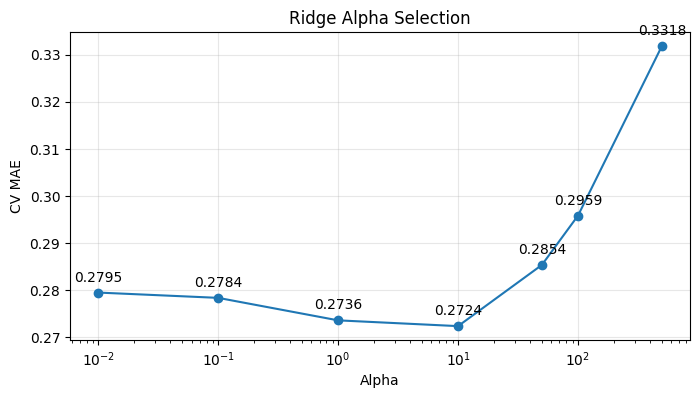

In [77]:
plt.figure(figsize=(8,4))

plt.plot(
    alpha_df["alpha"],
    alpha_df["mae_mean"],
    marker="o"
)

# Hiển thị giá trị trên từng điểm
for alpha_value, mae_value in zip(
    alpha_df["alpha"],
    alpha_df["mae_mean"]
):
    plt.annotate(
        f"{mae_value:.4f}",
        (alpha_value, mae_value),
        textcoords="offset points",
        xytext=(0,8),
        ha="center"
    )
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("CV MAE")
plt.title("Ridge Alpha Selection")
plt.grid(alpha=0.3)
plt.show()

### Nhận xét

Kết quả cho thấy `alpha = 10` đạt MAE thấp nhất trong các giá trị được thử nghiệm.

Điều này cho thấy một mức độ điều chuẩn vừa phải giúp mô hình giảm hiện tượng overfitting mà vẫn giữ được khả năng khai thác tín hiệu từ các đặc trưng đầu vào.

Do đó `alpha = 10` được lựa chọn làm tham số chính thức cho các mô hình Ridge trong nghiên cứu, bao gồm **Ridge A** và **Ridge B**.

#### **Select Best Alpha**

In [78]:
BEST_ALPHA = float(alpha_df.sort_values("mae_mean").iloc[0]["alpha"])
BEST_ALPHA

10.0

#### **Report Cell**

In [79]:
alpha_df.sort_values("mae_mean").head()

,alpha,mae_mean,mae_std,rmse_mean,rmse_std
3,10.00,0.272407,0.022841,0.367759,0.046842
2,1.00,0.273630,0.022783,0.373649,0.046467
1,0.10,0.278401,0.022150,0.381343,0.044711
0,0.01,0.279524,0.022048,0.383183,0.044389
4,50.00,0.285388,0.024840,0.381397,0.046749


### **10.3 Run Ridge A**

In [80]:
ridge_A = build_ridge_pipeline(preprocessor_A,alpha=BEST_ALPHA)

In [81]:
ridge_A_results = evaluate_model(
    model=ridge_A,
    X=X_A,
    y=y,
    cv=cv,
    stratify_labels=model_ready[
        "salary_bin"
    ]
)

In [82]:
ridge_A_results

,fold,mae,rmse
0,1,0.251341,0.317314
1,2,0.275450,0.395590
2,3,0.306595,0.430405
3,4,0.251394,0.328619
4,5,0.277254,0.366868


In [83]:
ridge_A_summary = get_model_summary(ridge_A_results)
ridge_A_summary

,mae,rmse
mean,0.272407,0.367759
std,0.022841,0.046842


**Nhận xét:** 

Kết quả cho thấy các đặc trưng metadata như `job title`, `location`, `source`, `education`, `job level` và `experience_years` mang tín hiệu dự đoán lương rất mạnh.


### **10.4 Run Ridge Model B**

#### **10.4.1 Preprocessor_B**
Vì **Feature Set B** có:

* categorical features
* numeric features
* skill aggregate features

nên phải tạo preprocessor riêng.

In [84]:
preprocessor_B = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_FEATURES_B
        ),
        (
            "num",
            StandardScaler(),
            NUMERIC_FEATURES_B
        )
    ]
)

#### **10.4.2 Ridge_B Pipeline**

In [85]:
ridge_B = build_ridge_pipeline(preprocessor_B,alpha=BEST_ALPHA)

#### **10.4.3 Evaluate Ridge B**

In [86]:
ridge_B_results = evaluate_model(
    model=ridge_B,
    X=X_B,
    y=y,
    cv=cv,
    stratify_labels=model_ready[
        "salary_bin"
    ]
)

#### **10.4.4 Results**

In [87]:
ridge_B_results

,fold,mae,rmse
0,1,0.248419,0.317133
1,2,0.267416,0.389931
2,3,0.304502,0.424333
3,4,0.248049,0.324789
4,5,0.274623,0.358486


In [88]:
ridge_B_summary = get_model_summary(ridge_B_results)
ridge_B_summary

,mae,rmse
mean,0.268602,0.362934
std,0.023218,0.044920


**Nhận xét:** 

Ridge B đạt **MAE = 0.268**, cải thiện thêm khoảng **1.8%** so với Ridge A (**0.273**).

Mặc dù mức cải thiện không lớn, kết quả cho thấy việc bổ sung các đặc trưng tổng hợp từ kỹ năng vẫn mang lại thêm tín hiệu dự đoán ngoài các thông tin metadata của tin tuyển dụng.

Điều này chứng minh rằng dữ liệu kỹ năng có đóng góp tích cực cho bài toán dự đoán lương.

#### **10.5 So sánh Ridge A và Ridge B**

In [89]:
comparison_df = pd.DataFrame(
    [
        {
            "model": "Global Median",
            "mae": baseline_median_df["mae"].mean(),
            "rmse": baseline_median_df["rmse"].mean()
        },
        {
            "model": "Median by Title",
            "mae": baseline_title_df["mae"].mean(),
            "rmse": baseline_title_df["rmse"].mean()
        },
        {
            "model": "Ridge A",
            "mae": ridge_A_results["mae"].mean(),
            "rmse": ridge_A_results["rmse"].mean()
        },
        {
            "model": "Ridge B",
            "mae": ridge_B_results["mae"].mean(),
            "rmse": ridge_B_results["rmse"].mean()
        }
    ]
)

comparison_df.sort_values("mae")

,model,mae,rmse
3,Ridge B,0.268602,0.362934
2,Ridge A,0.272407,0.367759
1,Median by Title,0.434313,0.613038
0,Global Median,0.493206,0.660563


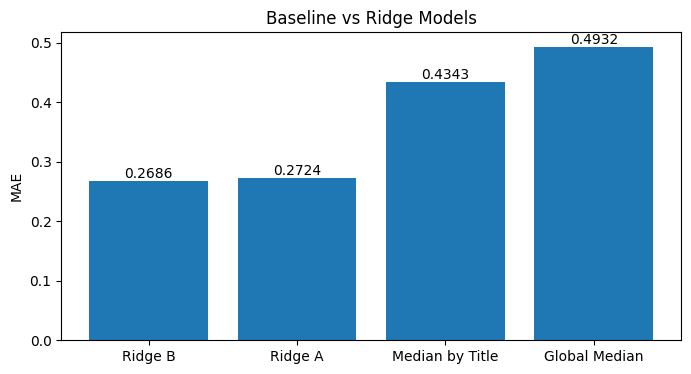

In [90]:
comparison_df = comparison_df.sort_values("mae")
comparison_df
plt.figure(figsize=(8,4))
bars = plt.bar(comparison_df["model"],comparison_df["mae"])
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f"{h:.4f}",
        ha="center",
        va="bottom"
    )
plt.ylabel("MAE")
plt.title("Baseline vs Ridge Models")
plt.show()

**Kết luận**

**Ridge Regression** cho thấy khả năng dự đoán lương vượt trội so với cả hai baseline.

Việc bổ sung các đặc trưng tổng hợp từ kỹ năng giúp cải thiện hiệu năng từ **Ridge A** sang **Ridge B**, chứng minh rằng thông tin kỹ năng có đóng góp tích cực cho bài toán.

Ngoài ra, quá trình tuning cho thấy `alpha = 10` là mức regularization phù hợp nhất trên tập dữ liệu hiện tại và được sử dụng cho các thí nghiệm Ridge tiếp theo.

## **SECTION 11 - Thử nghiệm Top-K Skills**

**Mục tiêu** của phần này là đánh giá liệu việc bổ sung các đặc trưng `One-Hot` biểu diễn **Top-K** kỹ năng phổ biến nhất có giúp cải thiện khả năng dự đoán lương hay không.

* Do các kỹ năng chuyên môn thường mang nhiều thông tin liên quan đến mức lương hơn so với kỹ năng mềm, nhóm **Soft Skill** được loại bỏ trước khi thực hiện các thí nghiệm **Top-K**.

* Nhiều giá trị K khác nhau được đánh giá thông qua **cross-validation** để xác định số lượng kỹ năng phù hợp nhất.

Trong các thí nghiệm **Top-K**, mô hình Ridge luôn sử dụng `BEST_ALPHA` đã được chọn ở **Section 10**. Điều này giúp đảm bảo việc so sánh giữa các cách biểu diễn kỹ năng phản ánh tác động của `feature engineering`, thay vì thay đổi siêu tham số của mô hình.

### **11.1 Tạo dataset loại Soft Skill**

Để đánh giá ảnh hưởng của các kỹ năng chuyên môn đối với bài toán dự đoán lương, nhóm Soft Skill được loại bỏ khỏi tập dữ liệu kỹ năng.

Tập dữ liệu mới sẽ được sử dụng để xây dựng các đặc trưng Top-K và so sánh với phiên bản sử dụng toàn bộ kỹ năng.

In [91]:
skills_no_soft = skills[skills["category"] != "Soft Skill"].copy()
print("Original:",len(skills))
print("Without Soft Skill:",len(skills_no_soft))

Original: 56335
Without Soft Skill: 47595


### **11.2 Xem Top 30 mới**

In [92]:
(skills_no_soft["final_canonical"].value_counts().head(30))

final_canonical
Domain Knowledge Other                        1288
Tool & Platform Other                         1088
Infrastructure & DevOps Other                 1041
Engineering Concepts & Methodologies Other    1021
Framework / Library Other                      557
python                                         546
AI/ML/Data Other                               538
Other Other                                    534
agile                                          494
sql                                            456
java                                           452
git                                            425
ci cd                                          420
Testing & QA Other                             416
restful api                                    387
docker                                         384
aws                                            352
javascript                                     344
microservices                                  312
Embedded & Firm

In [93]:
def evaluate_topk(k, skills_df, base_features):
    topk = (skills_df["final_canonical"].value_counts().head(k).index)
    
    skill_matrix = (
        pd.crosstab(
            skills_df["job_id"],
            skills_df["final_canonical"]
        )
        [list(topk)].reset_index()
    )
    
    model_k = (model_ready.merge(skill_matrix, on="job_id", how="left"))
    model_k[list(topk)] = (model_k[list(topk)].fillna(0))
    feature_cols = (
        base_features +
        list(topk)
    )

    X = model_k[feature_cols]

    cat_cols = [
        c for c in feature_cols
        if X[c].dtype == "object"
    ]

    num_cols = [
        c for c in feature_cols
        if c not in cat_cols
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore"),
                cat_cols
            ),
            (
                "num",
                StandardScaler(),
                num_cols
            )
        ]
    )

    ridge_topk = build_ridge_pipeline(
        preprocessor=preprocessor,
        alpha=BEST_ALPHA
    )

    results = evaluate_model(
        model=ridge_topk,
        X=X,
        y=y,
        cv=cv,
        stratify_labels=model_ready["salary_bin"]
    )

    return {
        "k": k,
        "mae": results["mae"].mean(),
        "rmse": results["rmse"].mean()
    }

### **11.3 Benchmark cho FEATURES_B**

In [94]:
k_values = [
    25,
    50,
    75,
    100,
    150,
    200
]

topk_B_results = []

for k in k_values:
    res = evaluate_topk(k=k, skills_df=skills_no_soft, base_features=FEATURES_B)
    topk_B_results.append(res)
topk_B_df = pd.DataFrame(topk_B_results)
topk_B_df.sort_values("mae")

,k,mae,rmse
0,25,0.272843,0.366903
1,50,0.273994,0.369437
2,75,0.276928,0.374170
3,100,0.279883,0.378564
4,150,0.292504,0.394128
5,200,0.301956,0.406551


### **11.4 Benchmark cho FEATURES_A**

In [95]:
topk_A_results = []

for k in k_values:
    res = evaluate_topk(k=k, skills_df=skills_no_soft, base_features=FEATURES_A)
    topk_A_results.append(res)
topk_A_df = pd.DataFrame(topk_A_results)
topk_A_df.sort_values("mae")

,k,mae,rmse
0,25,0.272250,0.367880
1,50,0.273259,0.369788
2,75,0.274148,0.373343
3,100,0.279068,0.379606
4,150,0.291664,0.394949
5,200,0.299283,0.403623


#### **11.4.1 Visualization**

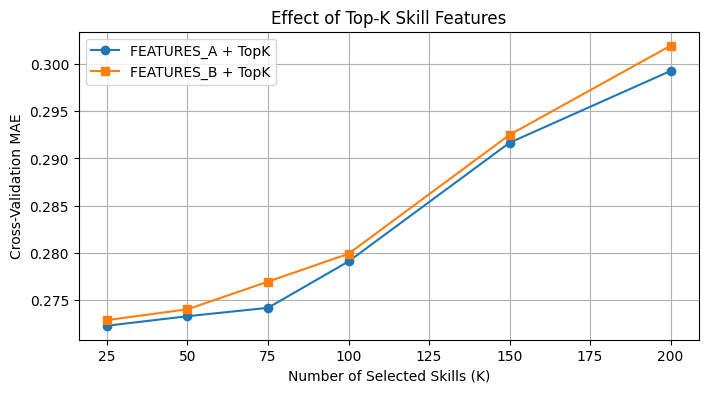

In [96]:
plt.figure(figsize=(8,4))

plt.plot(
    topk_A_df["k"],
    topk_A_df["mae"],
    marker="o",
    label="FEATURES_A + TopK"
)

plt.plot(
    topk_B_df["k"],
    topk_B_df["mae"],
    marker="s",
    label="FEATURES_B + TopK"
)

plt.xlabel("Number of Selected Skills (K)")
plt.ylabel("Cross-Validation MAE")
plt.title("Effect of Top-K Skill Features")
plt.legend()
plt.grid(True)

plt.show()

### **11.5 So sánh với Ridge A và Ridge B**

In [97]:
comparison_topk_df = pd.DataFrame(
    [
        {
            "model": "Ridge A",
            "mae": ridge_A_results["mae"].mean()
        },
        {
            "model": "Ridge B",
            "mae": ridge_B_results["mae"].mean()
        },
        {
            "model": "TopK A Best",
            "mae": topk_A_df["mae"].min()
        },
        {
            "model": "TopK B Best",
            "mae": topk_B_df["mae"].min()
        }
    ]
)
comparison_topk_df.sort_values("mae")

,model,mae
1,Ridge B,0.268602
2,TopK A Best,0.272250
0,Ridge A,0.272407
3,TopK B Best,0.272843


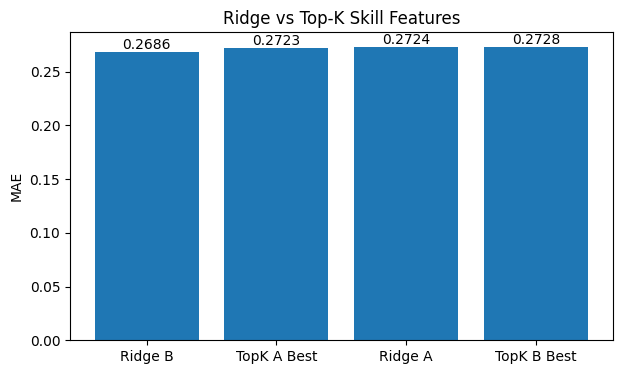

In [98]:
plt.figure(figsize=(7,4))
comparison_topk_df = (comparison_topk_df.sort_values("mae"))
bars = plt.bar(
    comparison_topk_df["model"],
    comparison_topk_df["mae"]
)
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f"{h:.4f}",
        ha="center",
        va="bottom"
    )
plt.ylabel("MAE")
plt.title("Ridge vs Top-K Skill Features")
plt.show()

### **11.6 Kết luận cuối cùng về biểu diễn kỹ năng**

1. Việc bổ sung một số kỹ năng phổ biến nhất dưới dạng **Top-K One-Hot Features** giúp cải thiện nhẹ hiệu năng so với `Ridge A` chỉ sử dụng **metadata**.

2. Khi tăng K vượt quá một ngưỡng nhất định, hiệu năng không tiếp tục cải thiện và có xu hướng suy giảm. Điều này cho thấy việc bổ sung quá nhiều kỹ năng hiếm không mang lại thêm tín hiệu hữu ích cho mô hình `Ridge`.

3. Bộ đặc trưng **Feature Set B** đạt kết quả tốt hơn tất cả các phiên bản sử dụng `Top-K Skills`.

### Quyết định cuối cùng

Mô hình cuối cùng sử dụng các đặc trưng kỹ năng tổng hợp (**Feature Set B**), bao gồm:

- số lượng kỹ năng,
- số lượng kỹ năng theo nhóm,
- số lượng kỹ năng theo mức độ,
- các đặc trưng kinh nghiệm liên quan đến kỹ năng.

Các đặc trưng one-hot biểu diễn **Top-K** kỹ năng không được sử dụng trong mô hình cuối cùng vì dù có thể cải thiện nhẹ so với `Ridge A`, chúng không vượt qua được **Feature Set B** dựa trên các đặc trưng kỹ năng tổng hợp, trong khi lại làm tăng độ thưa và kích thước không gian đặc trưng.

## **SECTION 12 - LightGBM (Feature Set A)**

**Mục tiêu:**

Kiểm tra liệu mô hình phi tuyến có khai thác **MetaData** tốt hơn `Ridge` hay không.

### **12.1 Cấu hình LightGBM cơ bản**

Một mô hình `LightGBM` đơn giản được huấn luyện trên **Feature Set A**.

Ở giai đoạn này, chưa thực hiện tối ưu siêu tham số (hyperparameter tuning).

Mục tiêu là đánh giá liệu một mô hình dựa trên cây quyết định (**tree-based model**) có thể vượt qua `Ridge Regression` khi sử dụng cùng một tập đặc trưng hay không.

Do `LightGBM` có khả năng học các mối quan hệ phi tuyến và tương tác giữa các đặc trưng, mô hình này được kỳ vọng sẽ khai thác tốt hơn các tín hiệu tiềm ẩn trong dữ liệu so với `Ridge Regression`.

In [99]:
lgbm_A = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_A
        ),
        (
            "model",
            LGBMRegressor(random_state=42, n_estimators=300)
        )
    ]
)

### **12.2 Evaluation**

Cross Validation Evaluation

In [100]:
X_A = model_ready[FEATURES_A]
y = model_ready[TARGET]
lgbm_A_results = evaluate_model(
    model=lgbm_A,
    X=X_A,
    y=y,
    cv=cv,
    stratify_labels=model_ready[
        "salary_bin"
    ]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001074 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 115
[LightGBM] [Info] Number of data points in the train set: 1180, number of used features: 50
[LightGBM] [Info] Start training from score 3.084161
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000611 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 111
[LightGBM] [Info] Number of data points in the train set: 1181, number of used features: 48
[LightGBM] [Info] Start training from score 3.095571
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000698 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, y

### **12.3 Fold Results**

In [101]:
lgbm_A_results

,fold,mae,rmse
0,1,0.250993,0.324290
1,2,0.275901,0.402496
2,3,0.308945,0.450321
3,4,0.256624,0.345209
4,5,0.270601,0.359991


### **12.4 Summary**

In [102]:
lgbm_A_summary = get_model_summary(lgbm_A_results)
lgbm_A_summary

,mae,rmse
mean,0.272613,0.376461
std,0.022682,0.050257


### **12.5 Compare với Ridge**

In [103]:
comparison_lgbm_A = pd.DataFrame(
    [
        {
            "model": "Baseline Median",
            "mae": baseline_median_df["mae"].mean()
        },
        {
            "model": "Baseline Title",
            "mae": baseline_title_df["mae"].mean()
        },
        {
            "model": "Ridge A",
            "mae": ridge_A_results["mae"].mean()
        },
        {
            "model": "LightGBM A",
            "mae": lgbm_A_results["mae"].mean()
        }
    ]
)

### **12.6 Visualization**

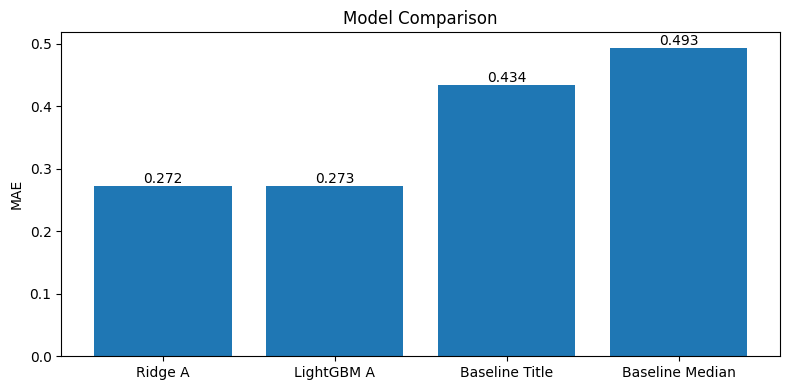

In [104]:
plt.figure(figsize=(8,4))
comparison_lgbm_A = (comparison_lgbm_A.sort_values("mae"))
bars = plt.bar(comparison_lgbm_A["model"],comparison_lgbm_A["mae"])
plt.ylabel("MAE")
plt.title("Model Comparison")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )
plt.tight_layout()
plt.show()

### **12.7 Nhận xét**

**LightGBM** cho kết quả tốt hơn **Ridge Regression** một chút trên **Feature Set A**.

Tuy nhiên, mức cải thiện là rất nhỏ (MAE 0.272 so với 0.273).

Điều này cho thấy phần lớn thông tin dự đoán được chứa trong các đặc trưng metadata có mối quan hệ gần tuyến tính với mức lương và đã được **Ridge Regression** khai thác khá hiệu quả.

Kết quả cũng cho thấy việc xây dựng đặc trưng (feature engineering) đóng vai trò quan trọng hơn so với việc tăng độ phức tạp của mô hình.

## **SECTION 13 - LightGBM (Feature Set B)**

**Mục tiêu:**

Metadata
+
Skill Aggregate Features
+
LightGBM

### **13.1 Feature Matrix**

**Feature Set B** includes:

- Metadata features
- Skill count features
- Skill category counts
- Skill level counts
- Experience requirement aggregates

In [105]:
X_B = model_ready[FEATURES_B]
y = model_ready["log_salary"]
print(X_B.shape)

(1476, 29)


### **13.2 Xác định categorical / numerical columns**

In [106]:
cat_cols_B = [c for c in FEATURES_B if X_B[c].dtype == "object"]
num_cols_B = [c for c in FEATURES_B if c not in cat_cols_B]
print("Categorical:", len(cat_cols_B))
print("Numerical:", len(num_cols_B))

Categorical: 6
Numerical: 23


### **13.3 Pipeline LightGBM B**

Một mô hình **LightGBM** được huấn luyện trên **Feature Set B**, bao gồm các đặc trưng metadata và các đặc trưng được xây dựng từ dữ liệu kỹ năng.

Quy trình cross-validation 5-fold được giữ nguyên nhằm đảm bảo khả năng so sánh trực tiếp với các mô hình đã đánh giá trước đó.

Thí nghiệm này nhằm kiểm tra liệu mô hình cây quyết định có thể khai thác hiệu quả hơn các đặc trưng kỹ năng so với **Ridge Regression** hay không.

In [107]:
preprocessor_B = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols_B
        ),
        (
            "num",
            StandardScaler(),
            num_cols_B
        )
    ]
)

lgbm_B = build_lgbm_pipeline(
    preprocessor=preprocessor_B
)

### **13.4 Cross Validation**

In [108]:
lgbm_B_results = evaluate_model(
    model=lgbm_B,
    X=X_B,
    y=y,
    cv=cv,
    stratify_labels=model_ready[
        "salary_bin"
    ]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001391 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 479
[LightGBM] [Info] Number of data points in the train set: 1180, number of used features: 72
[LightGBM] [Info] Start training from score 3.084161
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000843 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 480
[LightGBM] [Info] Number of data points in the train set: 1181, number of used features: 70
[LightGBM] [Info] Start training from score 3.095571
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000793 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, y

### **13.5 Fold Results**

In [109]:
lgbm_B_results

,fold,mae,rmse
0,1,0.255940,0.321050
1,2,0.280067,0.409104
2,3,0.298153,0.438519
3,4,0.263985,0.339869
4,5,0.293925,0.377852


### **13.6 Summary Statistics**

In [110]:
lgbm_B_summary = get_model_summary(lgbm_B_results)
lgbm_B_summary

,mae,rmse
mean,0.278414,0.377279
std,0.018346,0.048283


### **13.7 Compare với các model trước**

In [111]:
comparison_models = pd.DataFrame({
    "model": [
        "Baseline Median",
        "Baseline Title",
        "Ridge A",
        "LightGBM A",
        "Ridge B",
        "LightGBM B"
    ],
    "mae": [
        baseline_median_df["mae"].mean(),
        baseline_title_df["mae"].mean(),
        ridge_A_results["mae"].mean(),
        lgbm_A_results["mae"].mean(),
        ridge_B_results["mae"].mean(),
        lgbm_B_results["mae"].mean()
    ],
    "rmse": [
        baseline_median_df["rmse"].mean(),
        baseline_title_df["rmse"].mean(),
        ridge_A_results["rmse"].mean(),
        lgbm_A_results["rmse"].mean(),
        ridge_B_results["rmse"].mean(),
        lgbm_B_results["rmse"].mean()
    ]
})

### **13.8 Visualization**

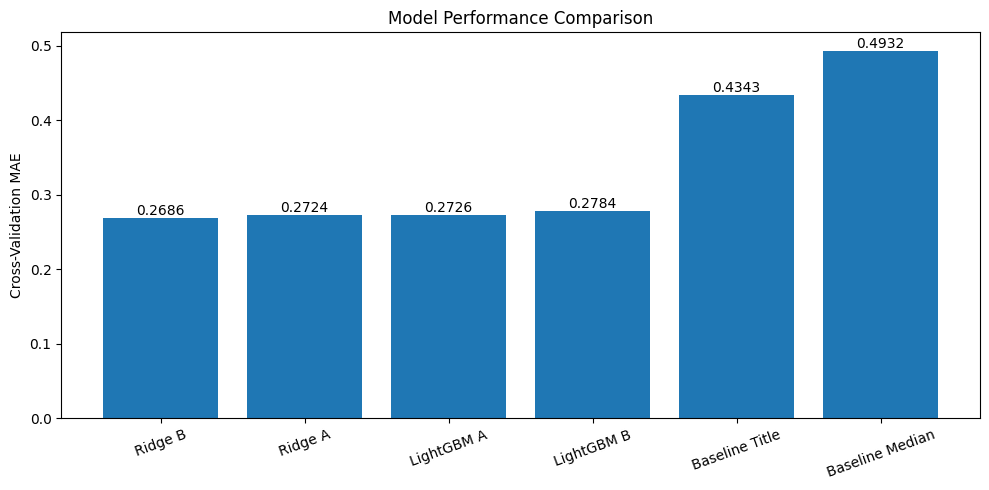

In [112]:
plot_df = comparison_models.sort_values("mae")
plt.figure(figsize=(10,5))
bars = plt.bar(plot_df["model"],plot_df["mae"])
plt.ylabel("Cross-Validation MAE")
plt.title("Model Performance Comparison")
plt.xticks(rotation=20)
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.4f}",
        ha="center",
        va="bottom"
    )
plt.tight_layout()
plt.show()

**Kết luận:**

Các đặc trưng metadata cung cấp phần lớn tín hiệu dự đoán mức lương.

Việc bổ sung các đặc trưng tổng hợp từ skill (Feature Set B) giúp cải thiện hiệu năng của mô hình `Ridge Regression`, với `Ridge B` đạt **MAE** thấp hơn `Ridge A`. Điều này cho thấy thông tin kỹ năng được trích xuất từ pipeline xử lý skill thực sự mang lại giá trị bổ sung cho bài toán dự đoán lương.

Ngược lại, `LightGBM B` không cải thiện so với `LightGBM A` trên tập dữ liệu hiện tại.

Trong tập dữ liệu hiện tại, các đặc trưng skill tổng hợp được `Ridge Regression` khai thác hiệu quả hơn `LightGBM`. Kết quả thực nghiệm cho thấy các đặc trưng skill tổng hợp phù hợp hơn với `Ridge Regression` trên tập dữ liệu hiện tại. Trong khi đó, LightGBM` không thu được cải thiện hiệu năng khi bổ sung cùng nhóm đặc trưng này.

Trong toàn bộ các mô hình được đánh giá, **Ridge B đạt kết quả tốt nhất** và được lựa chọn làm mô hình cuối cùng cho hệ thống dự đoán lương.

## **SECTION 14 - Model Comparison & Selection**

#### **14.1 Tổng hợp kết quả**

In [113]:
final_results = pd.DataFrame({
    "model": [
        "Baseline Median",
        "Baseline Title",
        "Ridge A",
        "Ridge B",
        "LightGBM A",
        "LightGBM B"
    ],
    "mae": [
        baseline_median_df["mae"].mean(),
        baseline_title_df["mae"].mean(),
        ridge_A_results["mae"].mean(),
        ridge_B_results["mae"].mean(),
        lgbm_A_results["mae"].mean(),
        lgbm_B_results["mae"].mean()
    ],
    "rmse": [
        baseline_median_df["rmse"].mean(),
        baseline_title_df["rmse"].mean(),
        ridge_A_results["rmse"].mean(),
        ridge_B_results["rmse"].mean(),
        lgbm_A_results["rmse"].mean(),
        lgbm_B_results["rmse"].mean()
    ]
})

final_results = final_results.sort_values("mae")
final_results

,model,mae,rmse
3,Ridge B,0.268602,0.362934
2,Ridge A,0.272407,0.367759
4,LightGBM A,0.272613,0.376461
5,LightGBM B,0.278414,0.377279
1,Baseline Title,0.434313,0.613038
0,Baseline Median,0.493206,0.660563


#### **14.2 Visualization**

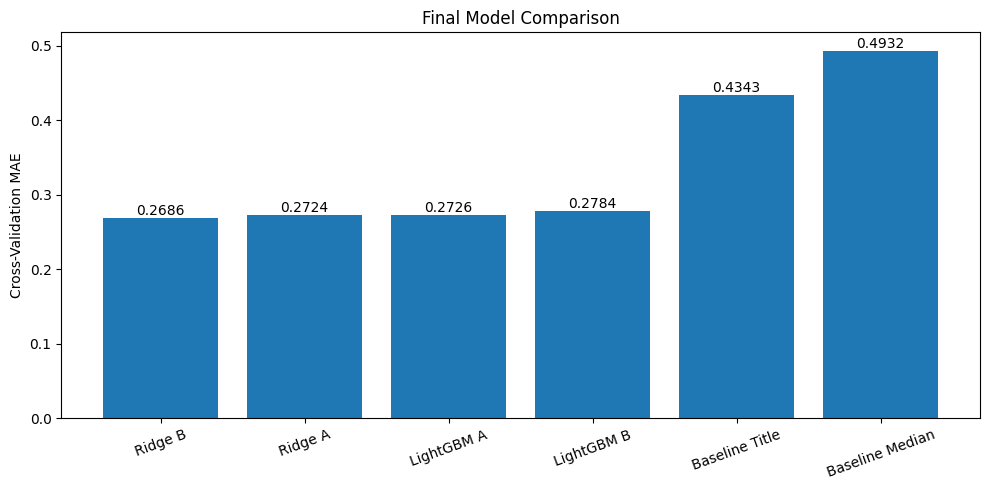

In [114]:
plt.figure(figsize=(10,5))

bars = plt.bar(final_results["model"],final_results["mae"])

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f"{h:.4f}",
        ha="center",
        va="bottom"
    )

plt.ylabel("Cross-Validation MAE")
plt.title("Final Model Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

#### **14.3 Best Model**

In [115]:
best_model = final_results.iloc[0]
best_model

model     Ridge B
mae      0.268602
rmse     0.362934
Name: 3, dtype: object

#### **14.4 Nhận xét**

`Ridge B` đạt **MAE** thấp nhất trong tất cả các mô hình được đánh giá và được lựa chọn là mô hình cuối cùng cho hệ thống dự đoán lương.

So với các model `Baseline`, `Ridge B` cải thiện đáng kể độ chính xác dự đoán, cho thấy các đặc trưng **metadata** và đặc trưng **kỹ năng tổng hợp** mang lại giá trị lớn cho bài toán.

Mặc dù `LightGBM` có khả năng mô hình hóa các quan hệ phi tuyến, kết quả thực nghiệm cho thấy `Ridge Regression` hoạt động tốt hơn trên tập dữ liệu hiện tại.

#### **14.5 Final Model Selection**

Mô hình cuối cùng được lựa chọn là `Ridge Regression` sử dụng **Feature Set B** với tham số a`lpha = 10`.

Bộ đặc trưng bao gồm:

- Metadata của tin tuyển dụng
- Skill count features
- Skill category features
- Skill level features
- Experience-related skill features

Mô hình này đạt hiệu năng tốt nhất trên đánh giá **cross-validation** và được sử dụng cho các phân tích tiếp theo.

#### **14.6 Statistical Significance Test**

**Paired t-test cho MAE**

In [116]:
t_stat, p_value = ttest_rel(
    ridge_A_results["mae"],
    ridge_B_results["mae"]
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 3.533916997506625
P-value: 0.024145231242740667


**Paired t-test cho RMSE**

In [117]:
t_stat_rmse, p_value_rmse = ttest_rel(
    ridge_A_results["rmse"],
    ridge_B_results["rmse"]
)

print("T-statistic:", t_stat_rmse)
print("P-value:", p_value_rmse)

T-statistic: 3.5257789067039944
P-value: 0.02432292501251642


**Bảng chênh lệch**

In [118]:
comparison_test = pd.DataFrame({
    "fold": range(1,6),
    "ridge_A_mae": ridge_A_results["mae"],
    "ridge_B_mae": ridge_B_results["mae"]
})

comparison_test["improvement"] = (
    comparison_test["ridge_A_mae"]
    -
    comparison_test["ridge_B_mae"]
)

comparison_test

,fold,ridge_A_mae,ridge_B_mae,improvement
0,1,0.251341,0.248419,0.002922
1,2,0.275450,0.267416,0.008034
2,3,0.306595,0.304502,0.002093
3,4,0.251394,0.248049,0.003345
4,5,0.277254,0.274623,0.002631


**Kết luận**

**Paired t-test** cho `MAE` và `RMSE` đều cho `p-value = 0.024 (< 0.05)`, cho thấy sự khác biệt giữa **Ridge A** và **Ridge B** **có ý nghĩa thống kê ở mức ý nghĩa 5%**.

Bên cạnh đó, **Ridge B** đạt kết quả tốt hơn **Ridge A** trên cả 5 fold Cross-Validation. Điều này cho thấy các đặc trưng kỹ năng tổng hợp đã đóng góp thêm thông tin hữu ích cho bài toán dự đoán lương.

Do đó, **Ridge Regression** với `Feature Set B` được lựa chọn làm mô hình cuối cùng của dự án.

#### **14.7 Correlation Analysis of Skill Features**

Để đánh giá liệu các đặc trưng kỹ năng có thực sự chứa tín hiệu liên quan đến mức lương hay không, nhóm tiến hành phân tích tương quan giữa các đặc trưng kỹ năng tổng hợp và biến mục tiêu `log_salary`.

In [119]:
agg_cols = AGG_FEATURES

corr_df = model_ready[agg_cols + ["log_salary"]].corr()

corr_df["log_salary"].sort_values(
    ascending=False
).head(20)

log_salary                                  1.000000
n_skills                                    0.423259
n_required                                  0.412200
has_year_requirement                        0.334045
cat_engineering_concepts_&_methodologies    0.331937
cat_infrastructure_&_devops                 0.244944
level_expert                                0.213477
cat_database                                0.205710
n_preferred                                 0.204611
cat_domain_knowledge                        0.161685
cat_programming_language                    0.159623
cat_framework___library                     0.140743
cat_other                                   0.129249
cat_data_engineering_&_analytics            0.119504
level_intermediate                          0.113840
cat_ai_ml_data                              0.079374
cat_soft_skill                              0.068618
cat_tool_&_platform                         0.051418
cat_testing_&_qa                            0.

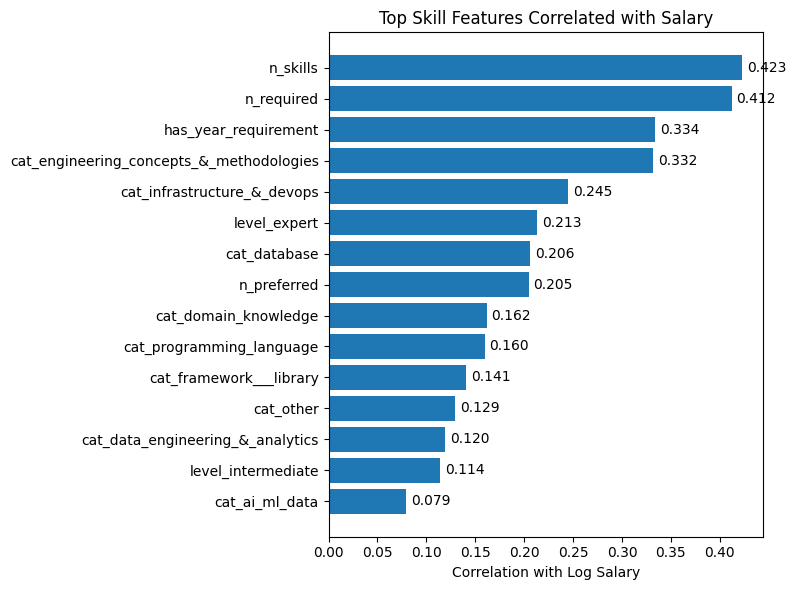

In [120]:
skill_corr = (
    corr_df["log_salary"]
    .drop("log_salary")
    .sort_values(ascending=True)
    .tail(15)
)

plt.figure(figsize=(8,6))

bars = plt.barh(
    skill_corr.index,
    skill_corr.values
)

plt.xlabel("Correlation with Log Salary")
plt.title("Top Skill Features Correlated with Salary")

for bar in bars:
    plt.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

**Kết luận:**

Kết quả cho thấy nhiều đặc trưng kỹ năng có mối liên hệ dương với mức lương và không phải toàn bộ tín hiệu đều đến từ **metadata** của tin tuyển dụng.

Đặc biệt, số lượng kỹ năng, số kỹ năng bắt buộc, yêu cầu kinh nghiệm và một số nhóm kỹ năng kỹ thuật chuyên sâu đều thể hiện mức tương quan đáng kể với `log_salary`.

Điều này cung cấp thêm bằng chứng rằng các đặc trưng kỹ năng tổng hợp mang thông tin hữu ích cho bài toán dự đoán lương, đồng thời giải thích vì sao **Feature Set B** đạt kết quả tốt hơn **Feature Set A** trong quá trình đánh giá mô hình.

## **SECTION 15 - Final Model Analysis**

Train Ridge B trên toàn bộ dữ liệu

In [121]:
final_model = ridge_B.fit(X_B,y)

### **15.1 - Model Coefficients**

Lấy tên feature sau preprocessing

In [122]:
feature_names = (final_model.named_steps["preprocessor"].get_feature_names_out())
coef = (final_model.named_steps["model"].coef_)
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef,
    "abs_coef": np.abs(coef)
})
coef_df = (coef_df.sort_values("abs_coef",ascending=False))
coef_df.head(30)

,feature,coef,abs_coef
87,cat__job_level_Intern,-0.833652,0.833652
191,num__experience_years,0.256410,0.256410
90,cat__job_level_Quản lý / Giám sát,0.251293,0.251293
147,cat__standardized_title_IT Support,-0.163243,0.163243
92,cat__job_level_Trưởng nhóm,0.162324,0.162324
30,cat__industry_Dược phẩm / Y tế / Công nghệ sin...,-0.157941,0.157941
93,cat__job_level_Trưởng/Phó phòng,0.156740,0.156740
6,cat__location_Foreign:Japan,0.153628,0.153628
170,cat__standardized_title_QA Engineer,-0.149686,0.149686
0,cat__source_itviec,0.147984,0.147984


#### **Plot Top 30**

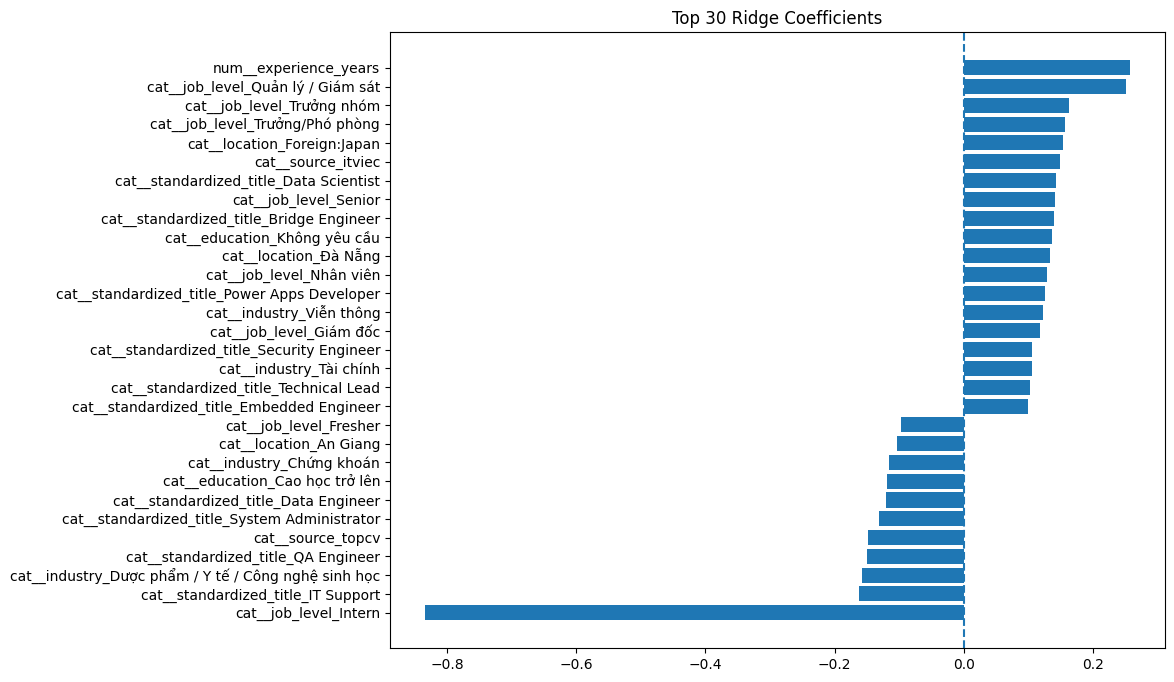

In [123]:
top30 = (coef_df.head(30).sort_values("coef"))
plt.figure(figsize=(10,8))
plt.barh( top30["feature"],top30["coef"])
plt.axvline(0, linestyle="--")
plt.title("Top 30 Ridge Coefficients")
plt.show()

#### **Nhận xét về Model Coefficients**

Kết quả phân tích hệ số của mô hình Ridge B cho thấy các đặc trưng liên quan đến **cấp bậc công việc, kinh nghiệm, nguồn tuyển dụng, chức danh công việc, địa điểm làm việc** và **ngành nghề** có ảnh hưởng mạnh nhất đến mức lương dự đoán.

**Các tín hiệu quan trọng nhất gồm:**

- **Experience Years** là đặc trưng số có hệ số dương lớn nhất. Điều này cho thấy số năm kinh nghiệm càng cao thì mức lương dự đoán càng tăng, phù hợp với thực tế thị trường lao động.

- **Job Level** là nhóm đặc trưng có ảnh hưởng mạnh nhất trong các biến phân loại. Các vị trí như **Quản lý/Giám sát**, **Trưởng nhóm**, **Trưởng/Phó phòng**, **Senior** và **Giám đốc** có hệ số dương đáng kể, trong khi **Intern** có hệ số âm rất lớn. Điều này phản ánh rõ mối quan hệ giữa cấp bậc công việc và mức lương.

- **Source** cũng mang nhiều tín hiệu dự báo. Các tin tuyển dụng từ **ITViec** có xu hướng gắn với mức lương cao hơn, trong khi **TopCV** có xu hướng thấp hơn mặt bằng chung của tập dữ liệu.

- **Standardized Title** đóng vai trò quan trọng trong dự đoán lương. Các vị trí như **Data Scientist**, **Bridge Engineer**, **Technical Lead**, **Security Engineer và Embedded Engineer** có hệ số dương, trong khi **IT Support, QA Engineer, System Administrator** và **Data Engineer** có hệ số âm tương đối lớn.

- **Location** cũng ảnh hưởng đáng kể đến dự đoán lương. Một số thị trường nước ngoài như **Japan** hoặc các khu vực có nhu cầu tuyển dụng cao cho thấy hệ số dương so với mặt bằng chung.

- **Industry** cung cấp thêm tín hiệu dự báo. Các ngành như **Tài chính, Viễn thông** và **Chứng khoán** xuất hiện trong nhóm hệ số có độ lớn cao, phản ánh sự khác biệt về mặt bằng lương giữa các lĩnh vực.

### **Kết luận**

Các hệ số lớn nhất của mô hình tập trung chủ yếu vào:

1. Cấp bậc công việc (Job Level)
2. Số năm kinh nghiệm (Experience Years)
3. Nguồn tuyển dụng (Source)
4. Chức danh công việc chuẩn hóa (Standardized Title)
5. Địa điểm làm việc (Location)
6. Ngành nghề (Industry)

Kết quả này phù hợp với hiểu biết nghiệp vụ về thị trường tuyển dụng CNTT và nhất quán với các kết quả phân tích dữ liệu trước đó. Đồng thời, nó cho thấy quy trình chuẩn hóa dữ liệu và xây dựng **Feature Set B** đã giúp mô hình khai thác được những tín hiệu quan trọng nhất liên quan đến mức lương.

### **15.2 - Out-of-Fold Prediction**

Tạo prediction CV thật sự


In [124]:
# Tạo oof thủ công
oof_pred = np.zeros(len(model_ready))
for train_idx, valid_idx in cv.split(X_B, model_ready["salary_bin"]):
    X_train = X_B.iloc[train_idx]
    X_valid = X_B.iloc[valid_idx]
    y_train = y.iloc[train_idx]
    model = clone(ridge_B)
    model.fit(X_train, y_train)
    oof_pred[valid_idx] = (model.predict(X_valid))

In [125]:
# Check
len(oof_pred)

1476

#### **Residual**

In [126]:
residual_df = pd.DataFrame({"actual": y,"pred": oof_pred})
residual_df["residual"] = (
    residual_df["actual"]
    -
    residual_df["pred"]
)

#### **Plot Actual vs Predicted**

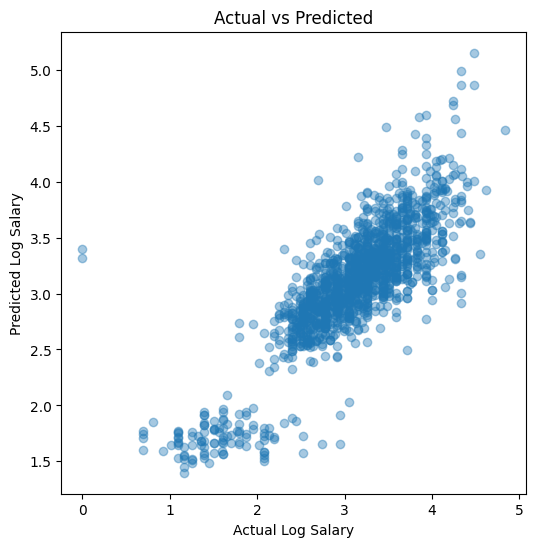

In [127]:
plt.figure(figsize=(6,6))
plt.scatter(
    residual_df["actual"],
    residual_df["pred"],
    alpha=0.4
)
plt.xlabel("Actual Log Salary")
plt.ylabel("Predicted Log Salary")
plt.title("Actual vs Predicted")
plt.show()

#### **Residual Histogram**

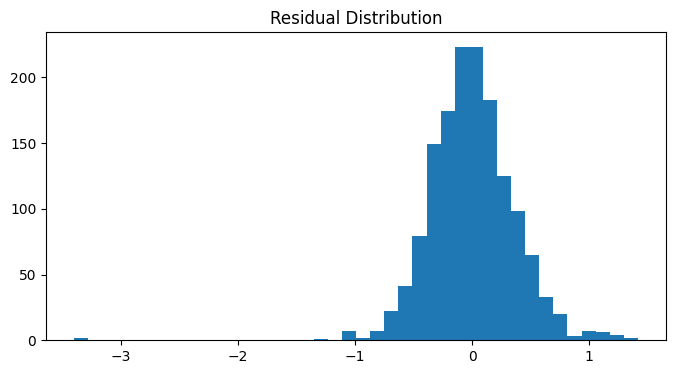

In [128]:
plt.figure(figsize=(8,4))
plt.hist(
    residual_df["residual"],
    bins=40
)
plt.title("Residual Distribution")
plt.show()

#### **Residual vs Prediction**

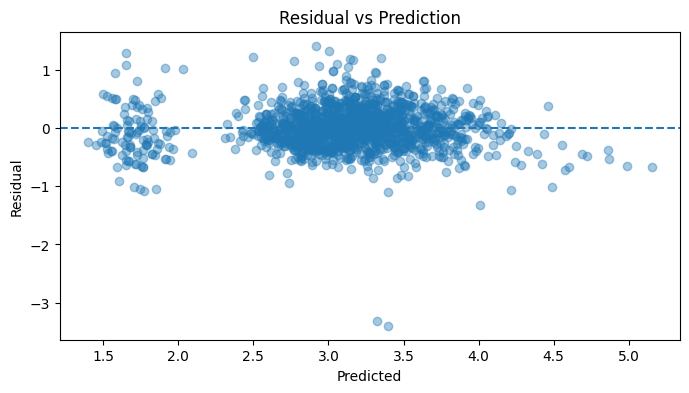

In [129]:
plt.figure(figsize=(8,4))
plt.scatter(
    residual_df["pred"],
    residual_df["residual"],
    alpha=0.4
)
plt.axhline(0,linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual vs Prediction")
plt.show()

**Phân tích phần dư (Residual Analysis)**

Phân phối phần dư tập trung khá cân đối quanh giá trị 0, cho thấy mô hình không có xu hướng **dự đoán cao hơn** hoặc **dự đoán thấp hơn** một cách có hệ thống.

Phần lớn sai số nằm trong khoảng **±0.2 đơn vị log-salary**, cho thấy độ chính xác dự đoán nhìn chung là tốt đối với đa số tin tuyển dụng.

Tuy nhiên, mô hình có xu hướng:

* **Đánh giá thấp (under-estimate)** đối với các mức lương rất cao.
* **Đánh giá cao (over-estimate)** đối với các mức lương rất thấp.

Đây là hiện tượng phổ biến của các mô hình tuyến tính có regularization như **Ridge Regression**, khi mô hình có xu hướng kéo các dự đoán về gần giá trị trung bình của tập dữ liệu.

Ngoài ra vẫn tồn tại một số trường hợp sai số rất lớn (outliers), cho thấy một số tin tuyển dụng có mức lương chịu ảnh hưởng bởi những yếu tố chưa được mô hình hóa đầy đủ từ metadata và các đặc trưng kỹ năng hiện có.


**Xem top lỗi lớn nhất**

In [130]:
worst_cases = (residual_df.assign(
        abs_error=lambda x:
        x["residual"].abs()
    )
    .sort_values(
        "abs_error",
        ascending=False
    )
)

worst_cases.head(20)

,actual,pred,residual,abs_error
550,0.000000,3.397709,-3.397709,3.397709
974,0.000000,3.321330,-3.321330,3.321330
14,4.330733,2.916228,1.414506,1.414506
615,4.330733,3.004923,1.325811,1.325811
1351,2.691243,4.010248,-1.319005,1.319005
410,2.944439,1.652394,1.292045,1.292045
1199,3.713572,2.497806,1.215766,1.215766
1473,4.551242,3.351003,1.200239,1.200239
1375,4.330733,3.144705,1.186029,1.186029
551,4.330733,3.162572,1.168161,1.168161


**Join lại với job_info**

In [131]:
worst_cases = (residual_df.assign(abs_error=lambda x: x["residual"].abs()))
worst_jobs = (
    model_ready.join(
        worst_cases[
            [
                "pred",
                "actual",
                "residual",
                "abs_error"
            ]
        ]
    )
    .sort_values("abs_error",ascending=False)
)
worst_jobs.head(20)

,job_id,job_title,location,experience,education,job_level,employment_type,industry,standardized_title,source,...,level_basic,level_expert,level_intermediate,required_experience_level,has_year_requirement,salary_bin,pred,actual,residual,abs_error
550,1020,BrSE ( Đào Tạo SAP),Hà Nội,2 năm,Đại Học trở lên,Nhân viên,Toàn thời gian,IT - Phần mềm,Bridge Engineer,topcv,...,0.0,0.0,1.0,2.0,1.0,0,3.397709,0.000000,-3.397709,3.397709
974,1796,Product Manager – Generics Product Group,Hồ Chí Minh,3 năm,Đại Học trở lên,Trưởng/Phó phòng,Toàn thời gian,Dược phẩm / Y tế / Công nghệ sinh học,Product Manager,topcv,...,0.0,4.0,0.0,0.0,0.0,0,3.321330,0.000000,-3.321330,3.321330
14,18,Power Apps Developer (HCM),Hồ Chí Minh,1 năm,Đại Học trở lên,Nhân viên,Toàn thời gian,IT - Phần mềm,Power Apps Developer,topcv,...,3.0,0.0,3.0,1.0,1.0,4,2.916228,4.330733,1.414506,1.414506
615,1143,BrSE - Kỹ Sư Cầu Nối JLPT Từ N3,Hà Nội,1 năm,Đại Học trở lên,Quản lý / Giám sát,Toàn thời gian,IT - Phần mềm,Business Analyst,topcv,...,0.0,2.0,1.0,1.0,1.0,4,3.004923,4.330733,1.325811,1.325811
1351,2668,Fresher Data Engineer,Hà Nội,6 năm,Đại học trở lên,Fresher,Toàn thời gian,IT Services and IT Consulting,Data Engineer,itviec,...,0.0,0.0,1.0,0.0,0.0,1,4.010248,2.691243,-1.319005,1.319005
410,726,"KỸ SƯ DỰ ÁN (Intern Full-Time, Fresher Are Wel...",Hà Nội,Không yêu cầu,Cao Đẳng trở lên,Intern,Toàn thời gian,IT - Phần mềm,Network Engineer,topcv,...,2.0,0.0,0.0,0.0,0.0,1,1.652394,2.944439,1.292045,1.292045
1199,2235,. NET Developer (Internal Product /Systems),Hà Nội,3 năm,Đại Học trở lên,Intern,Toàn thời gian,IT - Phần mềm,Backend Developer,topcv,...,1.0,2.0,1.0,3.0,1.0,4,2.497806,3.713572,1.215766,1.215766
1473,3176,VIETTEL SOLUTIONS - Solutions Architect,Hà Nội,2 năm,Đại học trở lên,Senior,Toàn thời gian,Telecommunication,Software Architect,itviec,...,0.0,0.0,3.0,0.0,0.0,4,3.351003,4.551242,1.200239,1.200239
1375,2778,JavaScript Engineer (Remote cho công ty Nhật Bản),Foreign:Japan,1 năm,Không yêu cầu,Nhân viên,Remote,Software Development Outsourcing,Fullstack Developer,itviec,...,0.0,7.0,1.0,0.0,0.0,4,3.144705,4.330733,1.186029,1.186029
551,1021,BrSE - Kỹ Sư Cầu Nối,Đà Nẵng,1 năm,Đại Học trở lên,Nhân viên,Toàn thời gian,IT - Phần mềm,Bridge Engineer,topcv,...,0.0,0.0,1.0,1.0,1.0,4,3.162572,4.330733,1.168161,1.168161


**Kết luận:**

Kết quả phân tích hệ số cho thấy cấp bậc công việc, số năm kinh nghiệm, nguồn tuyển dụng, chức danh công việc, địa điểm làm việc và ngành nghề là những tín hiệu dự báo lương quan trọng nhất trong dữ liệu. Các kết quả này phù hợp với hiểu biết nghiệp vụ và nhất quán với các phân tích khám phá dữ liệu trước đó.

Kết hợp với kết quả đánh giá mô hình ở **Section 14**, `Ridge B` đạt hiệu năng tốt nhất trong toàn bộ các mô hình được thử nghiệm và được lựa chọn làm mô hình cuối cùng cho hệ thống dự đoán lương.

## **Section 16 - Export**

In [132]:
# Lưu Final model
joblib.dump(final_model,"salary_predictor.joblib")

['salary_predictor.joblib']

In [133]:
with open("../data/processed/features_wide.parquet","rb") as f:
    file_hash = hashlib.md5(f.read()).hexdigest()
print(file_hash)

5c680a64e4ce18d7ef9bce20d9cc6186
